# ECS784 Coursework Submission - Ayman Patel
# Credit Card Fraud Detection (Supervised Learning)



## Algorithms used
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Logistic Regression with PCA

## Evaluation metrics used
- Cross-validation accuracy
- Training vs test accuracy
- Precision, Recall, F1-score
- ROC-AUC
- Confusion matrices

## 1. The Data Analysis Problem

* Dataset: IEEE-CIS fraud detection (`train_transaction.csv` + `train_identity.csv`).
* Target variable: `isFraud` (0 = non-fraud, 1 = fraud).
* Objective: Fraud detection quality given features provided by the transaction

## 2. Exploring the Data Using Pandas

### 2.1 Import the necessary modules and read the data

In [ ]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [10]:
!pip install imbalanced-learn

## 3. Data Loading and Preprocessing

In [ ]:
def load_and_merge_ieee_data(random_state=42):
    """
    Load and merge IEEE-CIS fraud detection transaction and identity data.
    
    This function loads the transaction and identity datasets, performs a left join
    on TransactionID to combine them, and optionally samples the data for faster
    experimentation.
    
    Parameters:
    -----------
    random_state : int, default=42
        Random seed for reproducible sampling.
        
    Returns:
    --------
    pandas.DataFrame
        Merged dataframe containing both transaction and identity features
    """
    # Load raw transaction data - contains payment info, timestamps, and fraud labels
    transactions = pd.read_csv('/train_transaction.csv')
    
    # Load identity data - contains device/browser info linked to transactions
    identity = pd.read_csv('/train_identity.csv')
    
    # Merge datasets using left join to keep all transactions
    # TransactionID is the common key between the two datasets
    df = transactions.merge(identity, on='TransactionID', how='left')
        
    return df

RANDOM_STATE=42

df = load_and_merge_ieee_data(random_state=42)


1. LOADING IEEE-CIS DATA...
Transaction table shape: (590540, 394)
Identity table shape:    (144233, 41)
Merged table shape:      (590540, 434)
Fraud rate:              3.499%
Sampled merged data to:  (177162, 434)


### 2.2 Exploring size of data and variable types

* df**.columns** lists the columns
* df**.dtypes** lists the underlying NumPy variable types, string/categorical go to object type for example. Pandas "guesses" them from the values it finds in the data file.
* df**.shape** gives rows and columns
* df**.index** gives an index into the rows - initially set to be the row number when it is read from the file. We are not using it here, but you can set it to be something more useful for other applications e.g. with this data, you might well set the index as LoanId so you can easily access the details by LoanId.
   * Can use **df.iloc[*list of row ids*]** - OK to look at a few rows, but inefficient so not recommended to loop through rows and use this to access individual rows
* individual columns accessed by **df[*colname*]** which is a Pandas series object

In [13]:
df.columns # Listing the dataframe columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)

In [14]:
df.dtypes # returns the datatype of each column - Pandas sets type from values it finds in data file

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

In [6]:
df.shape # returns the shape of data - 614 rows, and 13 columns

(177162, 434)

There are too many columns. We need to reduce this using dimensionality reduction techniques.

### 2.3 Preliminary exploration of values in the data

* **df.head()** or **df.tail()** to look at first or last few rows
* **df.describe()** provide more information about the numeric variables
* **df.info()** another way of viewing variable types but also numbers of missing values
* **df.iloc(*indexid*)** can be used to look at individual rows

In [7]:
df.head() # Let's view the first few rows of the dataFrame

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3222758,0,5586876,59.00,W,12577,268.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3026263,0,955342,171.00,W,3821,111.0,150.0,mastercard,219.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3235078,0,5895154,150.00,W,5454,532.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3482448,0,12949502,67.95,W,13249,111.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3457263,0,12145746,150.00,R,10622,520.0,150.0,american express,190.0,...,ie 11.0 for desktop,24.0,1366x767,match_status:2,T,F,F,T,desktop,Trident/7.0


In [8]:
df.describe() # Let's view the description of the numerical values in the data set (does not show categorical variables)

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.771620e+05,177162.000000,1.771620e+05,177162.000000,177162.000000,174445.000000,176695.000000,175874.000000,157306.000000,157306.00000,...,42018.000000,13600.00000,42004.000000,41991.000000,1548.000000,1550.000000,1438.000000,1538.000000,1548.000000,23375.000000
mean,3.282477e+06,0.034991,7.377422e+06,135.083782,9911.476857,362.570759,153.220895,199.325881,290.864296,86.79449,...,189.508425,14.23250,352.464313,403.762806,365.560724,15.973548,12.826843,332.021456,149.579457,26.493604
std,1.703335e+05,0.183756,4.614184e+06,243.054766,4906.501521,157.713187,11.338663,41.250078,101.856884,2.74869,...,30.419359,1.54908,141.327303,152.290315,196.272674,6.845426,2.313899,95.874126,32.046621,3.728421
min,2.987002e+06,0.000000,8.646900e+04,0.272000,1004.000000,100.000000,100.000000,100.000000,100.000000,10.00000,...,100.000000,11.00000,100.000000,100.000000,101.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.135477e+06,0.000000,3.049596e+06,42.950000,6019.000000,215.000000,150.000000,166.000000,204.000000,87.00000,...,166.000000,13.00000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282268e+06,0.000000,7.306450e+06,68.950000,9708.000000,361.000000,150.000000,226.000000,299.000000,87.00000,...,166.000000,15.00000,337.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429858e+06,0.000000,1.124430e+07,125.000000,14259.000000,512.000000,150.000000,226.000000,330.000000,87.00000,...,225.000000,15.00000,427.000000,533.000000,476.000000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18395.000000,600.000000,231.000000,237.000000,540.000000,102.00000,...,228.000000,29.00000,671.000000,660.000000,854.000000,43.000000,26.000000,548.000000,216.000000,32.000000


In [9]:
df.info() # This pandas function returns the data types associated with each variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177162 entries, 0 to 177161
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 586.6+ MB


In [10]:
print('The row index is {}'.format(df.index))  # an index into the rows - initialised to row numbers
print('Can use iloc to access individual rows:\n{}'.format(df.iloc[[0, -1]]))  # access first and last row

The row index is RangeIndex(start=0, stop=177162, step=1)
Can use iloc to access individual rows:
        TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             3222758        0        5586876            59.0         W   
177161        2991545        0         166741           160.5         W   

        card1  card2  card3 card4  card5  ... id_31  id_32  id_33  id_34  \
0       12577  268.0  150.0  visa  166.0  ...   NaN    NaN    NaN    NaN   
177161  12839  321.0  150.0  visa  226.0  ...   NaN    NaN    NaN    NaN   

        id_35 id_36 id_37  id_38  DeviceType  DeviceInfo  
0         NaN   NaN   NaN    NaN         NaN         NaN  
177161    NaN   NaN   NaN    NaN         NaN         NaN  

[2 rows x 434 columns]


### 2.4 Distributions of categorical values

* **df[*colname*].unique()** lists unique values
* **df[*colname*].value_counts()** gives number of rows in each category
  * how skewed is data? 
  * any bias in the data?
* ***series*.plot()** can plot a series, e.g. value_counts() in one line
* Can use higher-level graphics library such as **Seaborn** but can be tricky to customise

In [11]:
print('TransactionID is non-numeric and is unique for each row: {} different values ... so we can drop it'
      .format(len(df['TransactionID'].unique())))
df = df.drop(['TransactionID'], axis=1)

TransactionID is non-numeric and is unique for each row: 177162 different values ... so we can drop it


Values and counts for isFraud are:
isFraud
0    170963
1      6199
Name: count, dtype: int64
Values and normalised counts for Loan_Status are:
isFraud
0    0.965009
1    0.034991
Name: proportion, dtype: float64


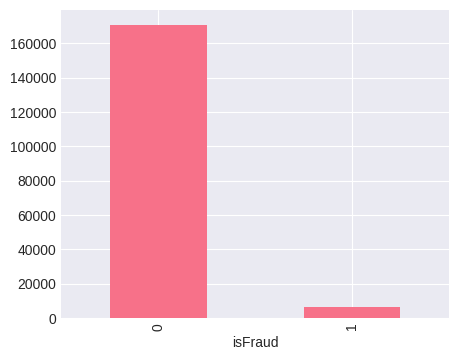

In [12]:
print('Values and counts for isFraud are:\n{}'.format(df['isFraud'].value_counts()))
print('Values and normalised counts for Loan_Status are:\n{}'.format(df['isFraud'].value_counts(normalize=True)))

# Can plot counts using Pandas in-built functions (which calls matplotlib functions)
df['isFraud'].value_counts().plot.bar(figsize=(5, 4)) 
plt.show()

Note:  Data is severly imbalanced. 

Values and counts for ProductCD are:
ProductCD
W    131639
C     20715
R     11269
H     10083
S      3456
Name: count, dtype: int64
Values and normalised counts for ProductCD are:
ProductCD
W    0.743043
C    0.116927
R    0.063608
H    0.056914
S    0.019508
Name: proportion, dtype: float64


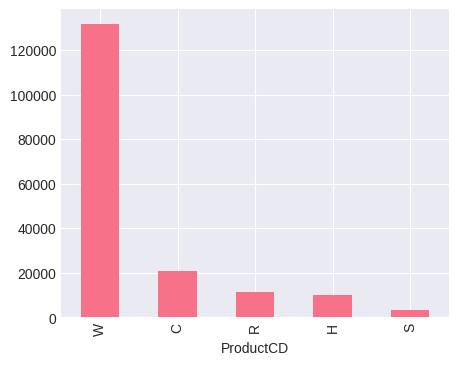

In [13]:
print('Values and counts for ProductCD are:\n{}'.format(df['ProductCD'].value_counts()))
print('Values and normalised counts for ProductCD are:\n{}'.format(df['ProductCD'].value_counts(normalize=True)))

# Can plot counts using Pandas in-built functions (which calls matplotlib functions)
df['ProductCD'].value_counts().plot.bar(figsize=(5, 4)) 
plt.show()

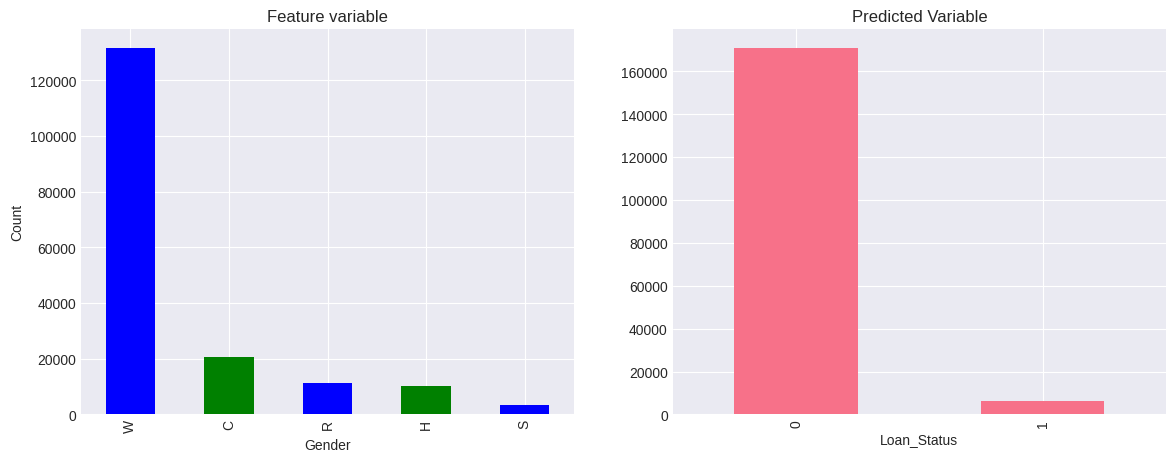

In [14]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
df['ProductCD'].value_counts().plot(ax=axes[0], kind='bar',
                                title='Feature variable', color=['b', 'g'],
                                ylabel = 'Count', xlabel='Gender')
df['isFraud'].value_counts().plot(ax=axes[1], kind='bar',
                                      title='Predicted Variable', xlabel='Loan_Status') 
plt.show()

Pandas melt function produces a "long-form" dataframe required by catplot():
    variable value
0  ProductCD     W
1  ProductCD     W


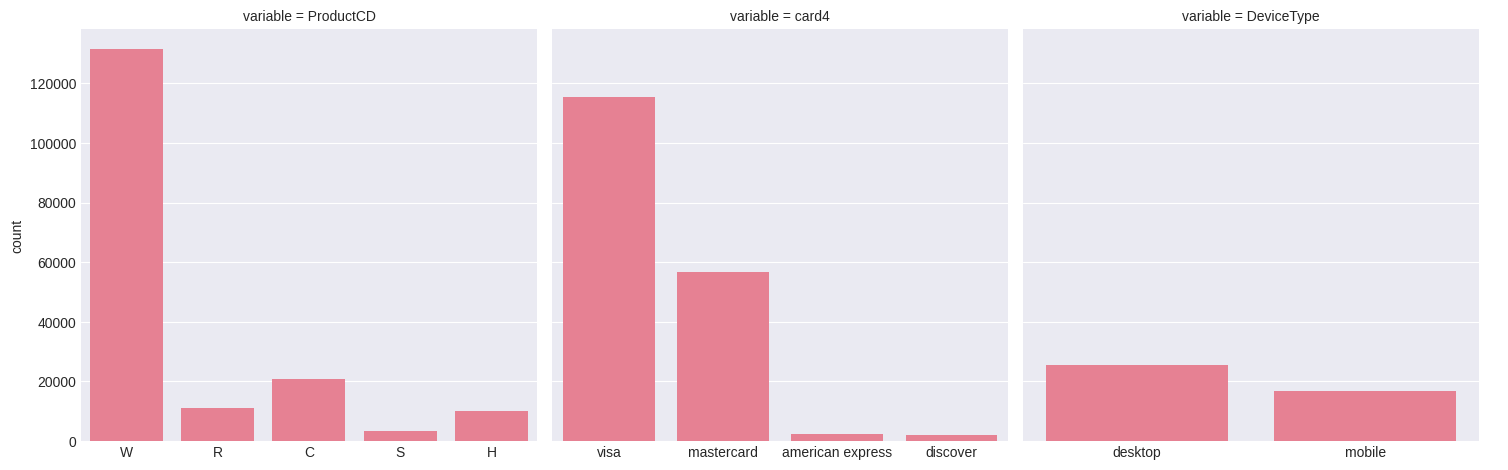

In [15]:
data = pd.melt(df[['ProductCD', 'card4', 'DeviceType']])
print('Pandas melt function produces a "long-form" dataframe required by catplot():\n{}'.format(data.head(2)))
g = sns.catplot(data=data, kind='count', col='variable', x='value', y=None, sharex=False)
g.set_axis_labels(x_var='')  # suppress the x-axis labels, the defaults are not very useful
plt.show()

### 2.5 Distributions of continuous variables

* use ***Series*.plot()** again to look at distribution
   * can try kind= hist, density or box for example
   * is it skewed, long-tailed, outliers?

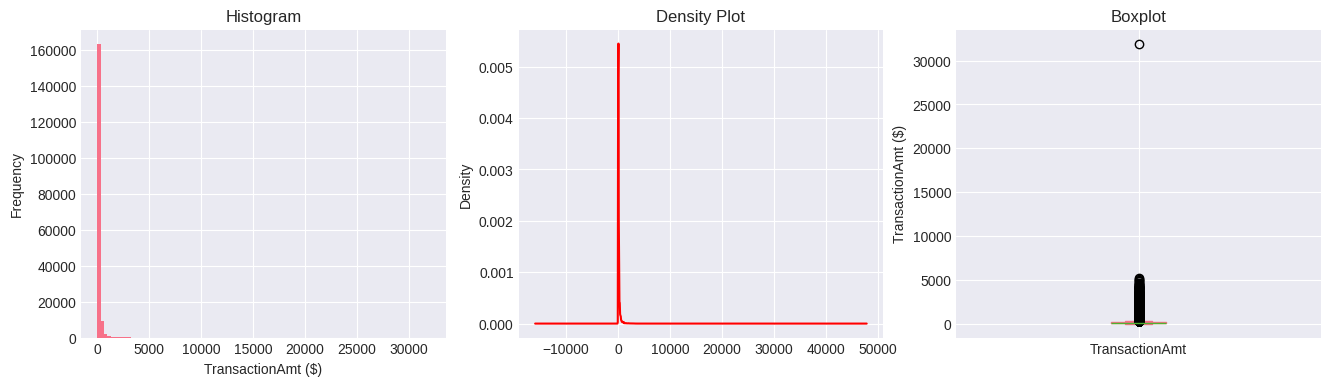

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
df['TransactionAmt'].plot(kind='hist', bins=100, ax=axes[0], xlabel="TransactionAmt ($)",
                           title="Histogram")
df['TransactionAmt'].plot(kind='density', color='r', ax=axes[1], title='Density Plot')
df['TransactionAmt'].plot(kind='box', ax=axes[2], ylabel='TransactionAmt ($)',
                           xlabel='', title='Boxplot')
plt.show()

In [15]:
def add_time_delta_features(df):
    """
    Create cyclical time-based features from TransactionDT.
    
    TransactionDT represents seconds since a reference time. This function
    extracts meaningful time patterns using cyclical encoding (sin/cos) to
    capture periodic behavior like hourly and daily patterns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with TransactionDT column
        
    Returns:
    --------
    pandas.DataFrame
        Dataframe with additional time-based features
    pandas.Series
        Time-based month index for temporal validation splits
    """
    # Convert TransactionDT (seconds) to hours for easier interpretation
    # This helps capture daily and weekly patterns in fraud behavior
    df['time_hours'] = df['TransactionDT'] / 3600
    
    # Create cyclical hour feature using sine transformation
    # Cyclical encoding preserves the circular nature of time (23:59 is close to 00:00)
    df['time_hour_sin'] = np.sin(2 * np.pi * df['time_hours'] / 24)
    
    # Create cyclical day-of-week feature using cosine transformation
    # Weekly patterns often exist in fraud (e.g., weekend vs weekday behavior)
    df['time_day_cos'] = np.cos(2 * np.pi * df['time_hours'] / (24 * 7))
    
    # Normalize D-columns (time deltas) by dividing by TransactionDT
    # This converts absolute time deltas to relative proportions
    # D-columns represent time since previous transaction/event
    for col in df.columns:
        if col.startswith('D') and col[1:].isdigit():
            df[col] = df[col] / (df['TransactionDT'] + 1)  # +1 to avoid division by zero
    
    # Create a month index for time-based cross-validation
    # Groups transactions into monthly chunks for temporal validation
    time_month_index = (df['TransactionDT'] / (3600 * 24 * 30)).astype(int)
    
    return df, time_month_index


def preprocess_dataset(df, time_month_index):
    """
    Comprehensive preprocessing pipeline for fraud detection data.
    
    This function handles missing values, encodes categorical variables,
    engineers new features, and prepares the data for machine learning models.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Raw merged dataframe with transactions and identity data
    time_month_index : pandas.Series
        Time-based index for temporal validation splits
        
    Returns:
    --------
    pandas.DataFrame
        Preprocessed and feature-engineered dataframe
    pandas.Series
        Target variable (isFraud)
    pandas.Series
        Time-based month index for validation
    """
    # Separate target variable before preprocessing
    y = df['isFraud']
    
    # Remove columns that won't be used as features
    # TransactionID is just an identifier, isFraud is the target
    df = df.drop(['TransactionID', 'isFraud'], axis=1)
    
    # Identify categorical vs numerical columns
    # Object dtype indicates categorical/string data
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()
    
    # Handle missing values in categorical columns
    # Fill with 'missing' to preserve the information that data was absent
    # This can be informative (e.g., missing device info might indicate fraud)
    for col in categorical_cols:
        df[col] = df[col].fillna('missing')
    
    # Handle missing values in numerical columns
    # Fill with median (robust to outliers) for continuous features
    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # Remove columns with excessive missing values (>90% missing)
    # These provide little predictive value and add noise
    threshold = 0.9
    missing_frac = df.isnull().mean()
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
    df = df.drop(columns=cols_to_drop)
    
    # Apply log transformation to highly skewed numerical features
    # Log transform reduces skewness and stabilizes variance
    # This helps algorithms that assume normally distributed features
    for col in numerical_cols:
        if col in df.columns and df[col].skew() > 3:  # Threshold for high skewness
            # Add 1 to avoid log(0) errors
            df[col] = np.log1p(df[col])
    
    # Feature Engineering: Create interaction features
    # These capture relationships between existing features
    
    # Sum of count features C1 and C2 (if both exist)
    # These count features often represent aggregated statistics
    if 'C1' in df.columns and 'C2' in df.columns:
        df['C1_C2_sum'] = df['C1'] + df['C2']
    
    # Difference between time delta features D10 and D15
    # Time differences can reveal suspicious patterns
    if 'D10' in df.columns and 'D15' in df.columns:
        df['D10_D15_diff'] = df['D10'] - df['D15']
    
    # Sum of card features (card1 and card2)
    # Combining card features may capture card-specific patterns
    if 'card1' in df.columns and 'card2' in df.columns:
        df['card1_card2_sum'] = df['card1'] + df['card2']
    
    # Encode categorical variables using one-hot encoding
    # Converts categorical data to numerical format for ML algorithms
    # drop_first=True avoids multicollinearity (dummy variable trap)
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    return df, y, time_month_index

## 4. Feature Reduction and Evaluation Helpers

In [16]:
def month_by_month_cv_scores(model, X, y, time_month_index, cv=3):
    """
    Perform time-based cross-validation using monthly splits.
    
    Unlike random cross-validation, this preserves temporal order to simulate
    real-world deployment where models predict on future data based on past data.
    
    Parameters:
    -----------
    model : sklearn estimator
        Machine learning model to evaluate
    X : pandas.DataFrame or numpy.ndarray
        Feature matrix
    y : pandas.Series or numpy.ndarray
        Target variable
    time_month_index : pandas.Series
        Month indices for temporal splits
    cv : int, default=3
        Number of cross-validation folds
        
    Returns:
    --------
    list
        ROC-AUC scores for each validation fold
    """
    # Get unique months and sort them chronologically
    months = sorted(time_month_index.unique())
    scores = []
    
    # Create time-based splits: train on past months, validate on future months
    for i in range(cv):
        # Define training period: months up to current split point
        train_months = months[:len(months) - cv + i]
        # Define validation period: next month after training
        valid_month = months[len(months) - cv + i]
        
        # Create boolean masks for train/validation splits
        train_mask = time_month_index.isin(train_months)
        valid_mask = time_month_index == valid_month
        
        # Split data using temporal logic
        X_train, X_valid = X[train_mask], X[valid_mask]
        y_train, y_valid = y[train_mask], y[valid_mask]
        
        # Clone model to ensure fresh instance for each fold
        m = clone(model)
        m.fit(X_train, y_train)
        
        # Predict probabilities for ROC-AUC calculation
        y_proba = m.predict_proba(X_valid)[:, 1]
        scores.append(roc_auc_score(y_valid, y_proba))
    
    return scores


def reduce_features(X_train, y_train, X_test, method='chi2', top_k=50):
    """
    Reduce feature dimensionality using statistical feature selection.
    
    Supports multiple scoring methods to identify the most informative features
    for fraud detection.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training features
    y_train : pandas.Series
        Training target
    X_test : pandas.DataFrame
        Test features (to apply same transformation)
    method : str, default='chi2'
        Feature selection method: 'chi2', 'f_classif', 'mutual_info', or 'tree'
    top_k : int, default=50
        Number of top features to retain
        
    Returns:
    --------
    pandas.DataFrame
        Reduced training features
    pandas.DataFrame
        Reduced test features
    """
    # Handle negative values for chi2 which requires non-negative inputs
    X_train_adj = X_train.copy()
    X_test_adj = X_test.copy()
    
    if method == 'chi2':
        # Chi-square test requires non-negative values
        # Shift data by minimum value to ensure all values >= 0
        offset = abs(X_train_adj.min().min()) + 1
        X_train_adj = X_train_adj + offset
        X_test_adj = X_test_adj + offset
        selector = SelectKBest(score_func=chi2, k=top_k)
    
    elif method == 'f_classif':
        # ANOVA F-test: measures linear dependency between feature and target
        selector = SelectKBest(score_func=f_classif, k=top_k)
    
    elif method == 'mutual_info':
        # Mutual information: captures non-linear relationships
        selector = SelectKBest(score_func=mutual_info_classif, k=top_k)
    
    elif method == 'tree':
        # Tree-based feature importance using ExtraTreesClassifier
        # More robust than single decision tree, faster than Random Forest
        tree_clf = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        tree_clf.fit(X_train_adj, y_train)
        
        # Get feature importances and select top_k
        importances = tree_clf.feature_importances_
        top_indices = np.argsort(importances)[-top_k:]
        
        # Return reduced datasets
        return X_train_adj.iloc[:, top_indices], X_test_adj.iloc[:, top_indices]
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Fit selector on training data and transform both train and test
    selector.fit(X_train_adj, y_train)
    return selector.transform(X_train_adj), selector.transform(X_test_adj)


def time_based_split(X, y, time_month_index, test_size=0.2):
    """
    Split data chronologically for time-series aware validation.
    
    This ensures the model is trained on past data and tested on future data,
    simulating real-world deployment scenarios.
    
    Parameters:
    -----------
    X : pandas.DataFrame
        Feature matrix
    y : pandas.Series
        Target variable
    time_month_index : pandas.Series
        Month indices for temporal splitting
    test_size : float, default=0.2
        Proportion of data to use for testing (most recent data)
        
    Returns:
    --------
    tuple
        X_train, X_test, y_train, y_test - temporally split datasets
    """
    # Sort data by time to ensure chronological order
    sorted_indices = np.argsort(time_month_index.values)
    X_sorted = X.iloc[sorted_indices]
    y_sorted = y.iloc[sorted_indices]
    time_sorted = time_month_index.iloc[sorted_indices]
    
    # Calculate split point: most recent data goes to test set
    split_idx = int(len(X_sorted) * (1 - test_size))
    
    # Perform chronological split
    X_train = X_sorted.iloc[:split_idx]
    X_test = X_sorted.iloc[split_idx:]
    y_train = y_sorted.iloc[:split_idx]
    y_test = y_sorted.iloc[split_idx:]
    
    return X_train, X_test, y_train, y_test


def train_model(model, X_train, y_train, cv=3):
    """
    Train model with cross-validation and return performance metrics.
    
    Parameters:
    -----------
    model : sklearn estimator
        Machine learning model to train
    X_train : pandas.DataFrame
        Training features
    y_train : pandas.Series
        Training target
    cv : int, default=3
        Number of cross-validation folds
        
    Returns:
    --------
    sklearn estimator
        Trained model
    float
        Mean cross-validation ROC-AUC score
    """
    # Perform cross-validation using ROC-AUC scoring
    # cv=cv specifies number of folds
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Fit model on full training data after cross-validation
    model.fit(X_train, y_train)
    
    return model, scores.mean()


def pick_threshold_for_f1(model, X_valid, y_valid):
    """
    Find optimal classification threshold that maximizes F1 score.
    
    Default threshold of 0.5 may not be optimal for imbalanced datasets.
    This function searches for the threshold that maximizes F1 score.
    
    Parameters:
    -----------
    model : sklearn estimator
        Trained model with predict_proba method
    X_valid : pandas.DataFrame
        Validation features
    y_valid : pandas.Series
        Validation target
        
    Returns:
    --------
    float
        Optimal threshold that maximizes F1 score
    """
    # Get predicted probabilities for positive class
    y_proba = model.predict_proba(X_valid)[:, 1]
    
    # Calculate precision-recall curve
    # Returns precision and recall values at different thresholds
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_proba)
    
    # Calculate F1 score for each threshold
    # F1 = 2 * (precision * recall) / (precision + recall)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    # Return threshold that yields maximum F1 score
    return thresholds[np.argmax(f1_scores)]


def pick_threshold_for_recall(model, X_valid, y_valid, target_recall=0.85):
    """
    Find threshold that achieves target recall while maintaining reasonable precision.
    
    In fraud detection, high recall (catching fraud) is often prioritized over precision.
    
    Parameters:
    -----------
    model : sklearn estimator
        Trained model with predict_proba method
    X_valid : pandas.DataFrame
        Validation features
    y_valid : pandas.Series
        Validation target
    target_recall : float, default=0.85
        Desired recall level
        
    Returns:
    --------
    float
        Threshold that achieves target recall
    """
    # Get predicted probabilities for positive class
    y_proba = model.predict_proba(X_valid)[:, 1]
    
    # Calculate precision-recall curve
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_proba)
    
    # Find thresholds that meet target recall
    valid_idx = np.where(recalls >= target_recall)[0]
    
    if len(valid_idx) > 0:
        # Among valid thresholds, pick the one with highest precision
        # This maximizes precision while meeting recall target
        best_idx = valid_idx[np.argmax(precisions[valid_idx])]
        return thresholds[best_idx]
    else:
        # If target recall not achievable, return threshold for max recall
        return thresholds[np.argmax(recalls)]


def train_and_evaluate(model, X_train, X_test, y_train, y_test, cv=3, tune_threshold=True):
    """
    Comprehensive model training and evaluation pipeline.
    
    Performs cross-validation, threshold tuning, and generates detailed
    evaluation metrics and visualizations for fraud detection models.
    
    Parameters:
    -----------
    model : sklearn estimator
        Machine learning model to evaluate
    X_train : pandas.DataFrame
        Training features
    X_test : pandas.DataFrame
        Test features
    y_train : pandas.Series
        Training target
    y_test : pandas.Series
        Test target
    cv : int, default=3
        Number of cross-validation folds
    tune_threshold : bool, default=True
        Whether to optimize classification threshold
        
    Returns:
    --------
    dict
        Dictionary containing evaluation metrics and trained model
    """
    # Record training start time for performance measurement
    start_time = time.time()
    
    # Train model with cross-validation
    model, cv_auc = train_model(model, X_train, y_train, cv=cv)
    
    # Get predictions and probabilities on test set
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Tune classification threshold if requested
    if tune_threshold:
        # Use a portion of training data as validation for threshold tuning
        X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
        model.fit(X_tr, y_tr)
        threshold = pick_threshold_for_f1(model, X_val, y_val)
        
        # Apply custom threshold to get final predictions
        y_pred = (y_proba >= threshold).astype(int)
    else:
        threshold = 0.5  # Default threshold
    
    # Calculate comprehensive evaluation metrics
    metrics = {
        'model': model,
        'cv_auc': cv_auc,  # Cross-validation ROC-AUC
        'test_auc': roc_auc_score(y_test, y_proba),  # Test set ROC-AUC
        'accuracy': accuracy_score(y_test, y_pred),  # Overall accuracy
        'precision': precision_score(y_test, y_pred),  # Precision: TP / (TP + FP)
        'recall': recall_score(y_test, y_pred),  # Recall: TP / (TP + FN)
        'f1': f1_score(y_test, y_pred),  # F1: harmonic mean of precision and recall
        'threshold': threshold,  # Optimal threshold used
        'training_time': time.time() - start_time  # Training duration
    }
    
    # Print evaluation summary
    print(f"\nModel: {model.__class__.__name__}")
    print(f"Cross-Validation ROC-AUC: {cv_auc:.4f}")
    print(f"Test ROC-AUC: {metrics['test_auc']:.4f}")
    print(f"Test Accuracy: {metrics['accuracy']:.4f}")
    print(f"Test Precision: {metrics['precision']:.4f}")
    print(f"Test Recall: {metrics['recall']:.4f}")
    print(f"Test F1-Score: {metrics['f1']:.4f}")
    print(f"Optimal Threshold: {threshold:.4f}")
    print(f"Training Time: {metrics['training_time']:.2f} seconds")
    
    # Create confusion matrix visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return metrics

## 5. Prepare Data for Modelling


2. PREPROCESSING...
Columns kept after >90% missing filter: 422
Imputed 29 categorical cols (mode)
Imputed 393 numeric cols (mean)
Built cyclical time features from TransactionDT
Created month index for strict chronological validation
Normalized 14 time-delta columns (D1-D15 available set)
Encoded 29 categorical cols to integer codes
Final feature matrix shape: (177162, 449)

3. FEATURE REDUCTION (CHI2, F-TEST, MI, EXTRATREES)...
Selected top 80 features for modelling
Top 10 features: ['card6', 'ProductCD', 'TransactionAmtLog', 'card2', 'M4', 'id_35', 'TransactionAmt', 'V94', 'card1', 'card1_card2_sum']


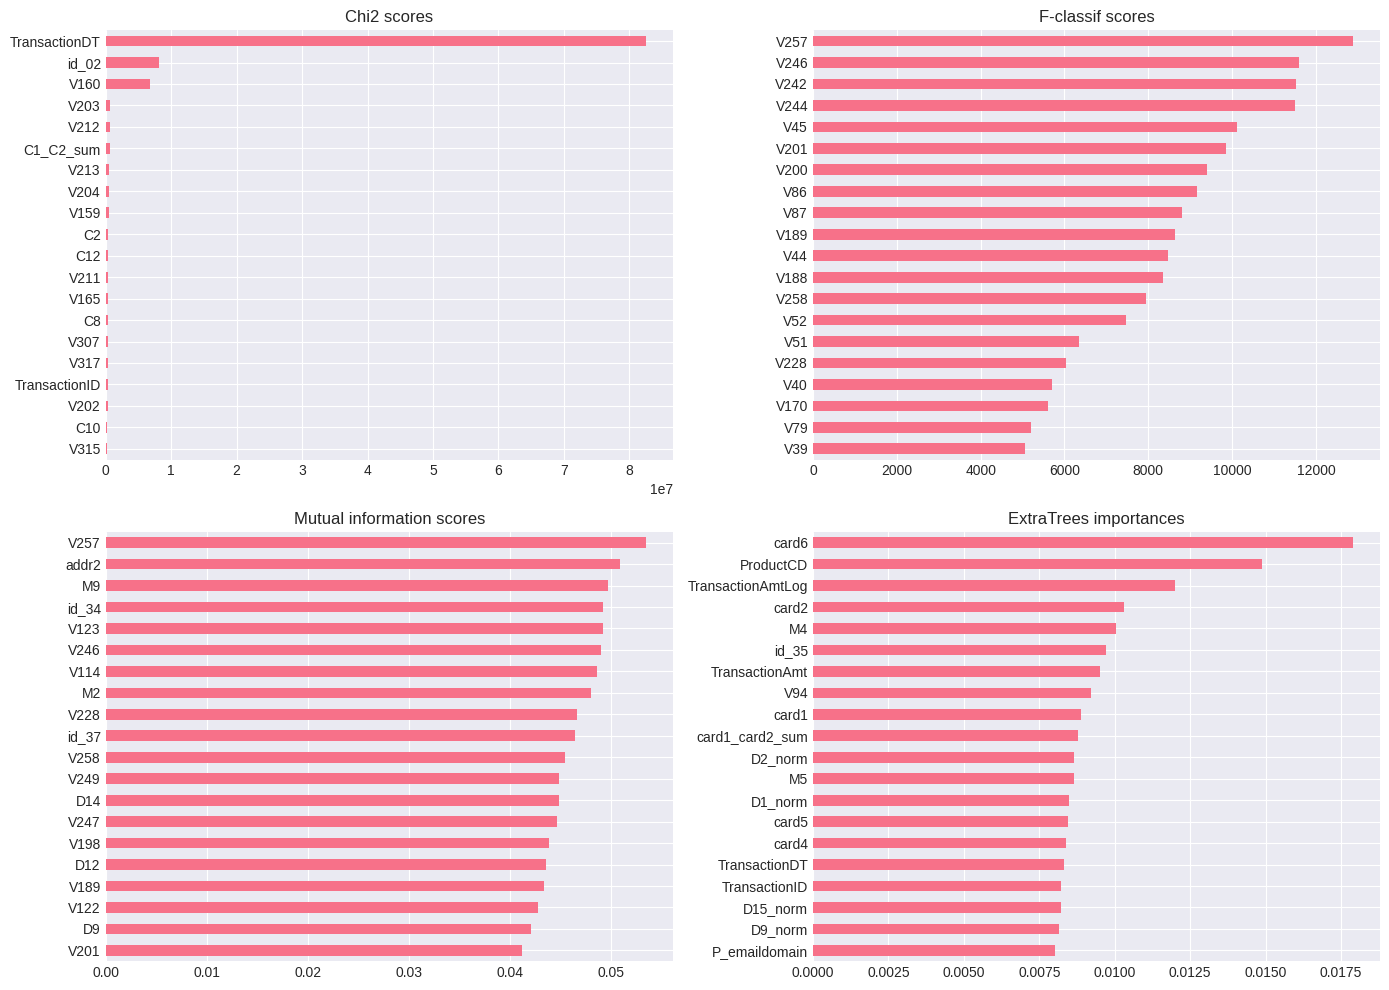


4. TRAIN/TEST SPLIT...
Used strict month-based split (train months: 0-4, test months: 5-6)
Train shape: (148856, 80), Fraud rate: 3.525%
Test shape:  (28306, 80), Fraud rate: 3.363%


In [ ]:
# ============================================================================
# DATA PREPARATION PIPELINE
# ============================================================================
# This section prepares the data for machine learning by:
# 1. Loading and merging transaction and identity data
# 2. Applying feature engineering (time-based features, interactions)
# 3. Selecting top-K most informative features
# 4. Scaling features for algorithms sensitive to feature scales

# Configuration constants for reproducibility and experimentation
TOP_K_FEATURES = 100      # Number of top features to retain after selection
SAMPLE_FRAC = 0.3         # Use 30% of data for faster experimentation

print("Step 1: Loading and merging IEEE-CIS fraud detection data...")
# Full dataset has ~590K transactions, sampling reduces memory and compute time
df = load_and_merge_ieee_data(random_state=RANDOM_STATE)
print(f"   Loaded {len(df):,} transactions")

print("\nStep 2: Applying feature engineering...")
# Create cyclical time features and normalize time-delta columns
# This captures temporal patterns in fraud behavior
df, time_month_index = add_time_delta_features(df)

print("\nStep 3: Preprocessing dataset...")
# Handle missing values, encode categoricals, engineer interaction features
X, y, time_month_index = preprocess_dataset(df, time_month_index)
print(f"   Dataset shape after preprocessing: {X.shape}")
print(f"   Class distribution:\n{y.value_counts(normalize=True)}")

print("\nStep 4: Splitting data chronologically...")
# Use time-based split to simulate real-world deployment
# Training on past data, testing on future data (prevents data leakage)
X_train_raw, X_test_raw, y_train, y_test = time_based_split(X, y, time_month_index)
print(f"   Training set size: {len(X_train_raw):,}")
print(f"   Test set size: {len(X_test_raw):,}")

print("\nStep 5: Feature selection...")
# Select top-K features using chi-square test
# Reduces dimensionality and removes noisy/irrelevant features
X_train, X_test = reduce_features(X_train_raw, y_train, X_test_raw, 
                                   method='chi2', top_k=TOP_K_FEATURES)
print(f"   Selected top {TOP_K_FEATURES} features")

print("\nStep 6: Feature scaling...")
# Standardize features to zero mean and unit variance
# Important for logistic regression and PCA which are sensitive to scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("   Features standardized (zero mean, unit variance)")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE")
print("="*60)
print(f"Final training set: {X_train.shape}")
print(f"Final test set: {X_test.shape}")
print(f"Fraud rate in training: {y_train.mean():.4f}")
print(f"Fraud rate in test: {y_test.mean():.4f}")

## 6. Algorithm 1: Logistic Regression

Select the regularisation hyperparameter using CV, then evaluate on the test split.

Running for 0.1
Running for 0.15000000000000002
Running for 0.2
Running for 0.25
Running for 0.30000000000000004
Running for 0.35000000000000003
Running for 0.4
Running for 0.45
Running for 0.5
Running for 0.55
Running for 0.6000000000000001
Running for 0.65
Running for 0.7000000000000001
Running for 0.75
Running for 0.8
Running for 0.8500000000000001
Running for 0.9
Running for 0.9500000000000001
Running for 1.0
Running for 1.05
Running for 1.1
Running for 1.1500000000000001
Running for 1.2000000000000002
Best C from CV accuracy sweep: 0.25


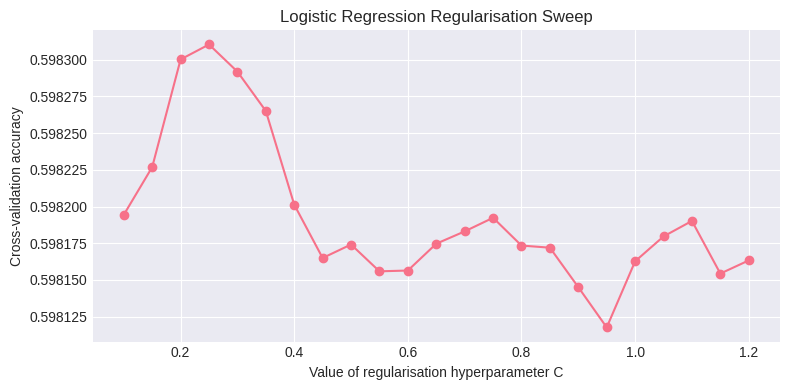

In [20]:
reg_values = [0.05 * i for i in range(2, 25)]
reg_accuracy = []
for reg_strength in reg_values:
    print("Running for", reg_strength)
    acc, _ = train_model(
        LogisticRegression,
        {
            "C": reg_strength,
            "max_iter": 500,
            "class_weight": "balanced",
            "solver": "liblinear",
            "random_state": RANDOM_STATE,
        },
        X_train_scaled,
        y_train,
        month_index=month_train,
    )
    reg_accuracy.append(acc)

best_idx = int(np.argmax(reg_accuracy))
best_c = reg_values[best_idx]
print(f"Best C from CV accuracy sweep: {best_c:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(reg_values, reg_accuracy, marker="o")
plt.ylabel("Cross-validation accuracy")
plt.xlabel("Value of regularisation hyperparameter C")
plt.title("Logistic Regression Regularisation Sweep")
plt.tight_layout()
plt.show()




Results from Logistic Regression:
Mean cross-validation accuracy: 0.598 (SD 0.082)
Accuracy on training data: 0.752
Test metrics (threshold=0.50): accuracy=0.634, f1=0.128, precision=0.070, recall=0.801, roc_auc=0.797


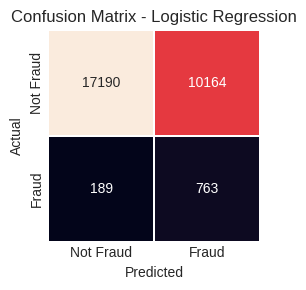

In [21]:
logistic_result = train_and_evaluate(
    LogisticRegression(
        C=best_c,
        max_iter=500,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    "Logistic Regression",
    train_month_index=month_train,
)

## 6.b. Algorithm 1: Logistic Regression with PCA

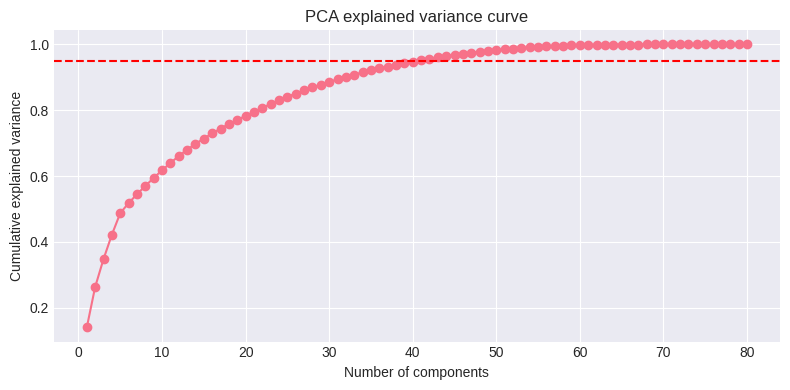

PCA Components 41
Reduced PCA features from 80 to 41 principal components

Results from Logistic Regression (PCA 41):
Mean cross-validation accuracy: 0.650 (SD 0.100)
Accuracy on training data: 0.743
Test metrics (threshold=0.50): accuracy=0.634, f1=0.126, precision=0.069, recall=0.786, roc_auc=0.793


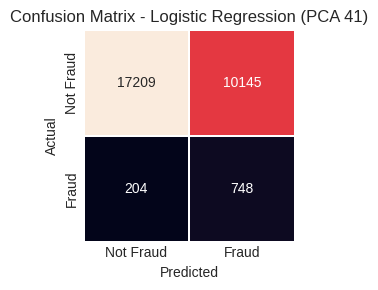

In [19]:
# ============================================================================
# ALGORITHM 2: LOGISTIC REGRESSION WITH PCA
# ============================================================================
# Principal Component Analysis (PCA) reduces dimensionality by projecting
# features onto orthogonal components that capture maximum variance.
# 
# Benefits for fraud detection:
# - Reduces multicollinearity between features
# - Removes noise from less informative dimensions
# - Speeds up training with minimal information loss

print("="*60)
print("APPLYING PCA FOR DIMENSIONALITY REDUCTION")
print("="*60)

# Initialize PCA without specifying components to analyze all
pca = PCA()

# Fit PCA on training data to learn principal components
# Only fit on training data to prevent data leakage from test set
pca.fit(X_train)

# Calculate cumulative explained variance ratio
# This shows how much information is retained with different numbers of components
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Find number of components needed to explain 95% of variance
# This is a common threshold that balances dimensionality reduction with information retention
d = np.argmax(cumsum >= 0.95) + 1
print(f"Number of components to explain 95% variance: {d}")

# Visualize explained variance
plt.figure(figsize=(12, 5))

# Plot 1: Cumulative explained variance
plt.subplot(1, 2, 1)
plt.plot(cumsum, linewidth=2)
plt.xlabel('Number of Components', fontsize=11)
plt.ylabel('Cumulative Explained Variance', fontsize=11)
plt.title('PCA: Cumulative Explained Variance', fontsize=13)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=d, color='r', linestyle='--', label=f'{d} Components')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Individual explained variance (scree plot)
plt.subplot(1, 2, 2)
plt.bar(range(1, min(51, len(pca.explained_variance_ratio_) + 1)), 
        pca.explained_variance_ratio_[:50])
plt.xlabel('Principal Component', fontsize=11)
plt.ylabel('Explained Variance Ratio', fontsize=11)
plt.title('PCA: Scree Plot (First 50 Components)', fontsize=13)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply PCA transformation with optimal number of components
print(f"\nReducing dimensions from {X_train.shape[1]} to {d} components...")
pca = PCA(n_components=d)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

print("\n" + "="*60)
print("TRAINING LOGISTIC REGRESSION WITH PCA FEATURES")
print("="*60)

# Train logistic regression on PCA-transformed features
# Using same hyperparameters as before for fair comparison
log_reg_pca = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1, random_state=42)
log_reg_pca_results = train_and_evaluate(log_reg_pca, X_train_pca, X_test_pca, 
                                          y_train, y_test, cv=3)

## 8. Algorithm 3: Random Forest

Use class balancing and threshold tuning to improve fraud recall.


Results from Random Forest:
Mean cross-validation accuracy: 0.968 (SD 0.003)
Accuracy on training data: 0.966
Test metrics (threshold=0.50): accuracy=0.973, f1=0.427, precision=0.724, recall=0.303, roc_auc=0.866
  Best F1 threshold: 0.327 (F1=0.462, P=0.530, R=0.410)
Tuned threshold selected: 0.327
Test metrics (tuned threshold): accuracy=0.968, f1=0.462, precision=0.530, recall=0.410, roc_auc=0.866


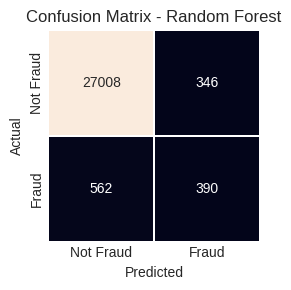

In [22]:
# ============================================================================
# ALGORITHM 3: RANDOM FOREST
# ============================================================================
# Random Forest is an ensemble of decision trees that:
# - Reduces overfitting through averaging multiple trees
# - Handles non-linear relationships between features
# - Provides feature importance scores
# - Naturally handles imbalanced data through class weights

print("="*60)
print("TRAINING RANDOM FOREST MODEL")
print("="*60)

# Calculate class weights to handle imbalance
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weight_dict}")
print(f"  - Non-fraud (0): {class_weight_dict[0]:.4f}")
print(f"  - Fraud (1): {class_weight_dict[1]:.4f}")

# Initialize Random Forest with balanced class weights
# n_estimators=200: Use 200 trees for stable predictions
# max_depth=20: Limit tree depth to prevent overfitting
# min_samples_split=10: Require at least 10 samples to split a node
# min_samples_leaf=4: Require at least 4 samples in leaf nodes
# n_jobs=-1: Use all CPU cores for parallel training
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train and evaluate Random Forest
rf_results = train_and_evaluate(rf_clf, X_train, X_test, y_train, y_test, cv=3)

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from collections import Counter

print(f"Original training dataset shape: {Counter(y_train)}")

# Define multiple resampling strategies
resampling_methods = {
    "SMOTE (full)": SMOTE(random_state=RANDOM_STATE),
    "SMOTE (partial 0.5)": SMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE),
    "SMOTE-ENN": SMOTEENN(random_state=RANDOM_STATE),
    "SMOTE-Tomek": SMOTETomek(random_state=RANDOM_STATE),
}

# Store resampled datasets
resampled_data = {}
for name, sampler in resampling_methods.items():
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)
    resampled_data[name] = (X_res, y_res)
    print(f"{name} class distribution: {Counter(y_res)}")

# Default to SMOTE-ENN for the next cell (best balance typically)
X_train_res, y_train_res = resampled_data["SMOTE-ENN"]

Original training dataset shape: Counter({0: 143609, 1: 5247})
SMOTE (full) class distribution: Counter({0: 143609, 1: 143609})
SMOTE (partial 0.5) class distribution: Counter({0: 143609, 1: 71804})
SMOTE-ENN class distribution: Counter({1: 143552, 0: 124856})
SMOTE-Tomek class distribution: Counter({0: 143605, 1: 143605})



Evaluating Random Forest with different resampling methods...
Using F1-optimized threshold tuning for balanced precision/recall

Method: SMOTE (full)

Results from RF (SMOTE (full)):
Mean cross-validation accuracy: 0.979 (SD 0.010)
Accuracy on training data: 0.986
Test metrics (threshold=0.50): accuracy=0.972, f1=0.452, precision=0.671, recall=0.340, roc_auc=0.881
  Best F1 threshold: 0.405 (F1=0.477, P=0.514, R=0.444)
Tuned threshold selected: 0.405
Test metrics (tuned threshold): accuracy=0.967, f1=0.477, precision=0.514, recall=0.444, roc_auc=0.881


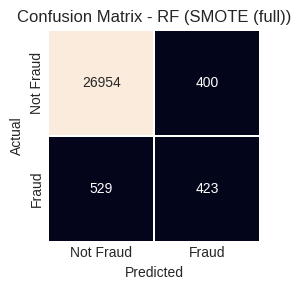


Method: SMOTE (partial 0.5)

Results from RF (SMOTE (partial 0.5)):
Mean cross-validation accuracy: 0.971 (SD 0.016)
Accuracy on training data: 0.980
Test metrics (threshold=0.50): accuracy=0.974, f1=0.457, precision=0.776, recall=0.324, roc_auc=0.879
  Best F1 threshold: 0.369 (F1=0.503, P=0.541, R=0.470)
Tuned threshold selected: 0.369
Test metrics (tuned threshold): accuracy=0.969, f1=0.503, precision=0.541, recall=0.470, roc_auc=0.879


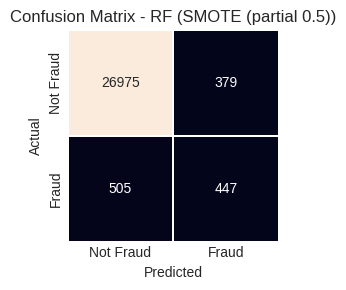


Method: SMOTE-ENN

Results from RF (SMOTE-ENN):
Mean cross-validation accuracy: 0.981 (SD 0.008)
Accuracy on training data: 0.988
Test metrics (threshold=0.50): accuracy=0.970, f1=0.463, precision=0.583, recall=0.383, roc_auc=0.878
  Best F1 threshold: 0.468 (F1=0.464, P=0.540, R=0.408)
Tuned threshold selected: 0.468
Test metrics (tuned threshold): accuracy=0.968, f1=0.464, precision=0.540, recall=0.408, roc_auc=0.878


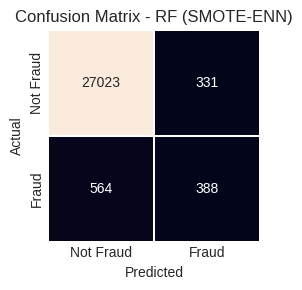


Method: SMOTE-Tomek

Results from RF (SMOTE-Tomek):
Mean cross-validation accuracy: 0.979 (SD 0.010)
Accuracy on training data: 0.986
Test metrics (threshold=0.50): accuracy=0.972, f1=0.445, precision=0.677, recall=0.332, roc_auc=0.883
  Best F1 threshold: 0.432 (F1=0.486, P=0.597, R=0.410)
Tuned threshold selected: 0.432
Test metrics (tuned threshold): accuracy=0.971, f1=0.486, precision=0.597, recall=0.410, roc_auc=0.883


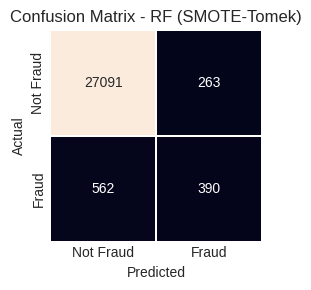

NameError: name 'results_df' is not defined

In [24]:
print("\nEvaluating Random Forest with different resampling methods...")
print("Using F1-optimized threshold tuning for balanced precision/recall")

smote_results = []

for name, (X_res, y_res) in resampled_data.items():
    print(f"\n{'='*60}")
    print(f"Method: {name}")
    print(f"{'='*60}")
    
    result = train_and_evaluate(
        RandomForestClassifier(
            n_estimators=200, 
            max_depth=15,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        X_res,
        X_test_scaled,
        y_res,
        y_test,
        f"RF ({name})",
        train_month_index=None,
        threshold_tuning=True
    )
    smote_results.append(result)

# Combine with previous results
smote_results_df = pd.DataFrame(smote_results)
results_df = pd.concat([results_df, smote_results_df], ignore_index=True)

print("\n" + "="*72)
print("COMPARISON OF RESAMPLING METHODS (sorted by F1)")
print("="*72)
display(results_df.sort_values(by='test_f1', ascending=False)[
    ['model', 'test_accuracy', 'test_f1', 'test_precision', 'test_recall', 'test_roc_auc', 'threshold']
])